# Multi-object video tracking with clicks

This is a simplified variant of `video_predictor_example.ipynb`: instead of typing point coordinates, you **click directly on frame 0** to prompt up to **8 objects**, then propagate all of them through the video with SAM 2 and watch the tracked result. Nothing is written to disk other than a temporary preview clip.

Requires the `ipympl` widget backend for interactive clicking (`pip install ipympl`).

## Set-up

In [14]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import shutil
import subprocess
import tempfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Video, display
from PIL import Image

In [15]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


### Loading the SAM 2 video predictor

In [16]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [17]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

#### Select an example video

SAM 2 operates on JPEG frames, so we extract them from the source MP4 with ffmpeg into a temporary directory. Swap `video_path` for your own clip to use a different video.

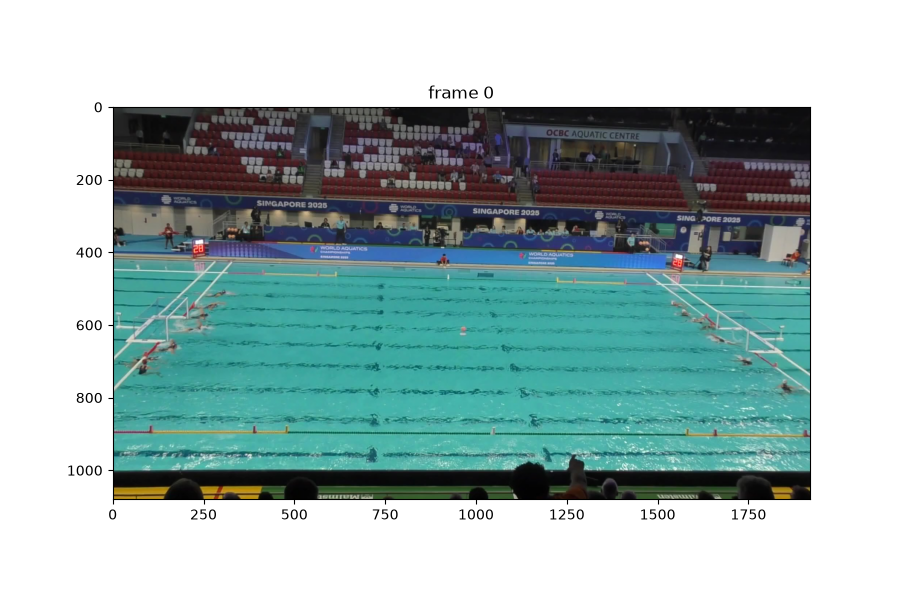

In [18]:
video_path = "./videos/clip_00_10.mp4"
N_OBJECTS = 8  # number of objects to prompt and track

assert shutil.which("ffmpeg"), "Install ffmpeg to extract frames from the video."
video_dir = tempfile.mkdtemp(prefix="sam2_frames_")
subprocess.run([
    "ffmpeg", "-hide_banner", "-loglevel", "error", "-y", "-i", video_path,
    "-q:v", "2", "-start_number", "0", os.path.join(video_dir, "%05d.jpg"),
], check=True)

frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

#### Initialize the inference state

In [19]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 500/500 [00:43<00:00, 11.38it/s]


## Click to prompt all 8 objects

Click directly on frame 0 below to prompt each object (no need to type coordinates):

- Press a number key **1-8** to select which object you're prompting (shown in the title).
- Click on the image to add a **positive** point for the selected object.
- Press **n** to toggle to a **negative** (exclude) click, press it again to go back to positive.
- Repeat until all 8 objects have at least one positive click, then run the tracking cell below.

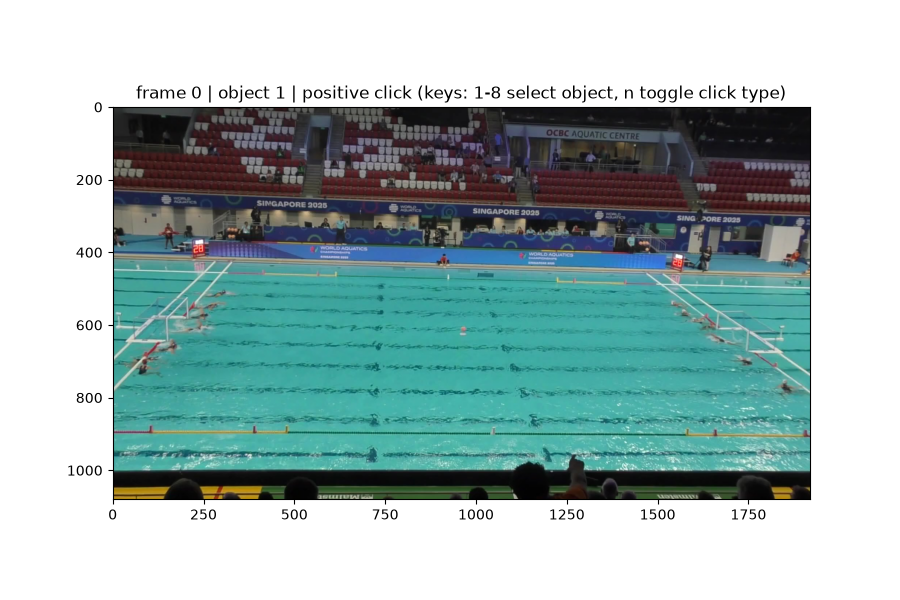

In [21]:
%matplotlib widget
predictor.reset_state(inference_state)

ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # currently selected object id, change with keys 1-8
ann_label = 1  # 1 = positive click, 0 = negative click, toggle with "n"
points_per_obj = {i: np.empty((0, 2), dtype=np.float32) for i in range(1, N_OBJECTS + 1)}
labels_per_obj = {i: np.empty((0,), dtype=np.int32) for i in range(1, N_OBJECTS + 1)}
masks_per_obj = {}

fig, ax = plt.subplots(figsize=(9, 6))

def render():
    ax.clear()
    mode = "positive" if ann_label == 1 else "negative"
    ax.set_title(f"frame {ann_frame_idx} | object {ann_obj_id} | {mode} click (keys: 1-8 select object, n toggle click type)")
    ax.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
    for obj_id, mask in masks_per_obj.items():
        show_mask(mask, ax, obj_id=obj_id)
    for obj_id in range(1, N_OBJECTS + 1):
        if len(points_per_obj[obj_id]):
            show_points(points_per_obj[obj_id], labels_per_obj[obj_id], ax)
    fig.canvas.draw_idle()

def onclick(event):
    if event.inaxes != ax or event.xdata is None or fig.canvas.toolbar.mode:
        return
    points_per_obj[ann_obj_id] = np.concatenate(
        [points_per_obj[ann_obj_id], [[event.xdata, event.ydata]]], axis=0
    ).astype(np.float32)
    labels_per_obj[ann_obj_id] = np.concatenate(
        [labels_per_obj[ann_obj_id], [ann_label]]
    ).astype(np.int32)
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=ann_frame_idx,
        obj_id=ann_obj_id,
        points=points_per_obj[ann_obj_id],
        labels=labels_per_obj[ann_obj_id],
    )
    for i, obj_id in enumerate(out_obj_ids):
        masks_per_obj[obj_id] = (out_mask_logits[i] > 0.0).cpu().numpy()
    render()

def onkey(event):
    global ann_obj_id, ann_label
    if event.key in [str(i) for i in range(1, N_OBJECTS + 1)]:
        ann_obj_id = int(event.key)
        render()
    elif event.key == "n":
        ann_label = 0 if ann_label == 1 else 1
        render()

fig.canvas.mpl_connect("button_press_event", onclick)
fig.canvas.mpl_connect("key_press_event", onkey)
render()

## Propagate and preview the tracked video

Run this once all 8 objects have at least one click. The annotated video is written to a temporary file only for playback and is deleted afterwards.

In [ ]:
missing = [obj_id for obj_id in range(1, N_OBJECTS + 1) if not (labels_per_obj[obj_id] == 1).any()]
if missing:
    raise ValueError(f"Add a positive click for object(s): {missing}")

height, width = np.array(Image.open(os.path.join(video_dir, frame_names[0]))).shape[:2]
cmap = plt.get_cmap("tab10")
# downscale the preview so the embedded video stays small enough to play inline
PREVIEW_WIDTH = 640
preview_width = min(width, PREVIEW_WIDTH)
preview_height = int(height * preview_width / width)

with tempfile.TemporaryDirectory() as tmp_dir:
    raw_video = os.path.join(tmp_dir, "tracked_preview_raw.mp4")
    playable_video = os.path.join(tmp_dir, "tracked_preview.mp4")
    writer = cv2.VideoWriter(raw_video, cv2.VideoWriter_fourcc(*"mp4v"), 24, (preview_width, preview_height))
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        rgb = np.array(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])).convert("RGB"))
        for i, obj_id in enumerate(out_obj_ids):
            mask = (out_mask_logits[i] > 0.0).cpu().numpy().reshape(height, width)
            color = np.array(cmap(obj_id)[:3]) * 255
            rgb[mask] = (rgb[mask] * 0.55 + color * 0.45).astype(np.uint8)
        rgb = cv2.resize(rgb, (preview_width, preview_height), interpolation=cv2.INTER_AREA)
        writer.write(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    writer.release()
    # OpenCV's mp4v fourcc isn't playable in browsers; re-encode to H.264/yuv420p.
    subprocess.run([
        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y", "-i", raw_video,
        "-c:v", "libx264", "-crf", "23", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        playable_video,
    ], check=True)
    print(f"Preview size: {os.path.getsize(playable_video) / 1e6:.1f} MB")
    display(Video(playable_video, embed=True, width=preview_width))

propagate in video:  38%|███▊      | 188/500 [00:43<01:13,  4.24it/s]

propagate in video: 100%|██████████| 500/500 [01:54<00:00,  4.36it/s]


Preview size: 3.3 MB
